# Machine Learning Models on MTG Cards Dataset

This notebook implements and compares three machine learning models:
- **K-Nearest Neighbors (KNN)**
- **Perceptron**
- **Naive Bayes**

Dataset: `all_mtg_cards.csv`

## 1. Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore the Dataset

In [41]:
def parse_cr(cr): # Needed to parse floats from fractions in CR column
    if isinstance(cr, str) and "/" in cr:
        num, den = cr.split("/")
        return float(num) / float(den)
    return float(cr)


# Load the dataset
df = pd.read_csv('dnd_monsters.csv')
df["cr"] = df["cr"].apply(parse_cr) # Convert from String to Float

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (762, 17)

Column names:
['name', 'url', 'cr', 'type', 'size', 'ac', 'hp', 'speed', 'align', 'legendary', 'source', 'str', 'dex', 'con', 'int', 'wis', 'cha']

First few rows:


,name,url,cr,type,size,ac,hp,speed,align,legendary,source,str,dex,con,int,wis,cha
0,aarakocra,https://www.aidedd.org/dnd/monstres.php?vo=aar...,0.25,humanoid (aarakocra),Medium,12,13,fly,neutral good,NaN,Monster Manual (BR),10.0,14.0,10.0,11.0,12.0,11.0
1,abjurer,NaN,9.00,humanoid (any race),Medium,12,84,NaN,any alignment,NaN,Volo's Guide to Monsters,NaN,NaN,NaN,NaN,NaN,NaN
2,aboleth,https://www.aidedd.org/dnd/monstres.php?vo=abo...,10.00,aberration,Large,17,135,swim,lawful evil,Legendary,Monster Manual (SRD),21.0,9.0,15.0,18.0,15.0,18.0
3,abominable-yeti,NaN,9.00,monstrosity,Huge,15,137,NaN,chaotic evil,NaN,Monster Manual,NaN,NaN,NaN,NaN,NaN,NaN
4,acererak,NaN,23.00,undead,Medium,21,285,NaN,neutral evil,NaN,Adventures (Tomb of Annihilation),NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       762 non-null    str    
 1   url        401 non-null    str    
 2   cr         761 non-null    float64
 3   type       762 non-null    str    
 4   size       762 non-null    str    
 5   ac         762 non-null    int64  
 6   hp         762 non-null    int64  
 7   speed      248 non-null    str    
 8   align      762 non-null    str    
 9   legendary  43 non-null     str    
 10  source     762 non-null    str    
 11  str        401 non-null    float64
 12  dex        401 non-null    float64
 13  con        401 non-null    float64
 14  int        401 non-null    float64
 15  wis        401 non-null    float64
 16  cha        401 non-null    float64
dtypes: float64(7), int64(2), str(8)
memory usage: 101.3 KB


In [43]:
# Statistical summary
df.describe()

,cr,ac,hp,str,dex,con,int,wis,cha
count,761.000000,762.000000,762.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000
mean,5.552398,14.577428,88.129921,15.231920,12.745636,15.147132,8.324190,11.820449,10.097257
std,6.254149,3.140581,94.822305,6.492964,3.183573,4.383012,5.694264,3.093167,5.696755
min,0.000000,0.000000,0.000000,1.000000,1.000000,8.000000,1.000000,2.000000,1.000000
25%,0.500000,12.000000,22.000000,11.000000,10.000000,12.000000,3.000000,10.000000,6.000000
50%,3.000000,14.000000,58.000000,16.000000,13.000000,14.000000,8.000000,12.000000,9.000000
75%,9.000000,17.000000,126.000000,19.000000,15.000000,17.000000,12.000000,13.000000,14.000000
max,30.000000,25.000000,676.000000,30.000000,28.000000,30.000000,26.000000,27.000000,30.000000


## 3. Data Preprocessing

In [44]:
# TODO: Choose your target variable (what you want to predict)
# Example: target = 'cr'  # or 'size', 'str', etc.

target = 'cr'

# Check target variable distribution
print(f"Target variable: {target}")
print(f"\nTarget distribution:")
print(df[target].value_counts())
print(f"\nMissing values in target: {df[target].isna().sum()}")

Target variable: cr

Target distribution:
cr
2.000     85
1.000     64
0.250     63
5.000     57
0.000     56
3.000     54
0.500     50
4.000     37
0.125     29
7.000     27
6.000     25
9.000     24
10.000    22
8.000     22
13.000    20
11.000    18
12.000    15
16.000    12
23.000    11
14.000    11
17.000    10
15.000     9
21.000     8
20.000     8
18.000     6
22.000     4
24.000     4
19.000     4
26.000     3
30.000     2
25.000     1
Name: count, dtype: int64

Missing values in target: 1


In [47]:
# TODO: Select relevant features for analysis. Here's a list of all the column names:
# name, multiverse_id, layout, names, mana_cost, cmc, colors, color_identity, type, supertypes, subtypes, rarity, text,
# flavor, artist, number, power, toughness, loyalty, variations, watermark, border, timeshifted, hand, life, reserved,
# release_date, starter, rulings, foreign_names, printings, original_text, original_type, legalities, source, image_url,
# set, set_name, id
feature_columns = ['size', 'str', 'hp']

# Create a copy of the dataframe
df_clean = df.copy()

# Remove rows with missing target values
df_clean = df_clean.dropna(subset=[target])

# Now drop rows with missing values for selected feature columns
df_clean = df_clean.dropna(subset=feature_columns)

# Note: Not including power/toughness since many spells don't have these values
# Might consider adding them later to analyze only creatures

# Remove duplicates, keeping entries with more non-null values (more info)
df_clean = df_clean.sort_values(by=df_clean.columns.tolist(), 
                                  key=lambda col: col.notna(), 
                                  ascending=False)
df_clean = df_clean.drop_duplicates(subset=['name'], keep='first')

print(f"Clean dataset shape: {df_clean.shape}")

Clean dataset shape: (401, 17)


In [ ]:
# Encode categorical features (colors and type are text, need to be converted to numbers)
label_encoders = {}

# These columns contain categorical text data that needs encoding
categorical_columns = ['size']

for col in categorical_columns:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded '{col}': {len(le.classes_)} unique values")

# Target is already numeric (0 or 1), so no encoding needed
y = df_clean[target].values

# Prepare features (now all numeric!)
X = df_clean[feature_columns].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {feature_columns}")

Encoded 'colors': 41 unique values
Encoded 'type': 3097 unique values

Features shape: (29049, 3)
Target shape: (29049,)
Feature columns: ['cmc', 'colors', 'type']


## 4. Train-Test Split

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintains class distribution
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature scaling (important for KNN and Perceptron)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed.")

Training set size: 23239
Testing set size: 5810

Feature scaling completed.


## 5. Model Training and Evaluation

### 5.1 K-Nearest Neighbors (KNN)

In [26]:
# Create and train KNN model
knn = KNeighborsClassifier(n_neighbors=7)  # 7 is proven to be the most accurate
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate the model
print("=== K-Nearest Neighbors Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Cross-validation score
cv_scores_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores_knn}")
print(f"Mean CV score: {cv_scores_knn.mean():.4f} (+/- {cv_scores_knn.std() * 2:.4f})")

=== K-Nearest Neighbors Results ===
Accuracy: 0.9437

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.22      0.36       402
           1       0.95      1.00      0.97      5408

    accuracy                           0.94      5810
   macro avg       0.90      0.61      0.66      5810
weighted avg       0.94      0.94      0.93      5810


Cross-validation scores: [0.9503012  0.94384682 0.94341652 0.94320138 0.94448031]
Mean CV score: 0.9450 (+/- 0.0053)


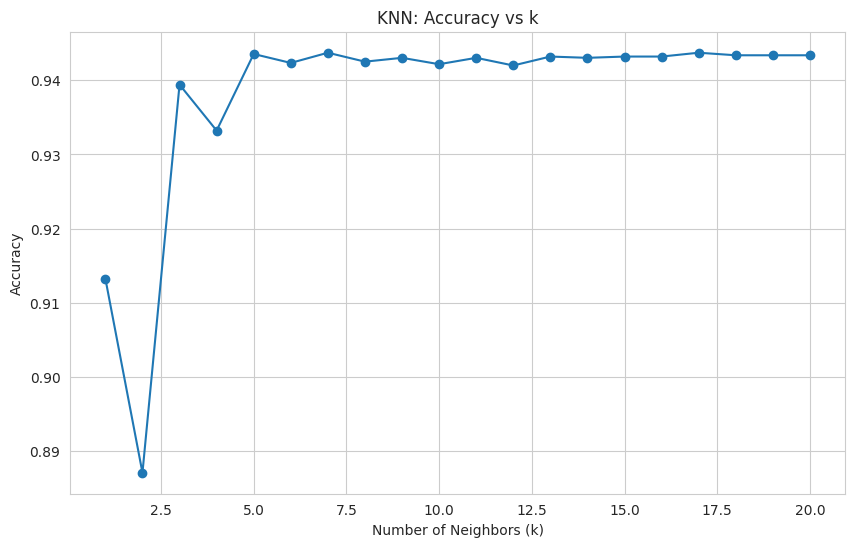

Best k: 7 with accuracy: 0.9437


In [27]:
# Experiment with different values of k
k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    k_scores.append(knn_temp.score(X_test_scaled, y_test))

# Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs k')
plt.grid(True)
plt.show()

print(f"Best k: {k_values[np.argmax(k_scores)]} with accuracy: {max(k_scores):.4f}")

### 5.2 Perceptron

In [28]:
# Create and train Perceptron model
perceptron = Perceptron(
    max_iter=10000,  # Adjustable max iterations
    random_state=42,
    eta0=0.7  # Learning rate
)
perceptron.fit(X_train_scaled, y_train)

# Make predictions
y_pred_perceptron = perceptron.predict(X_test_scaled)

# Evaluate the model
print("=== Perceptron Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_perceptron):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_perceptron))

# Cross-validation score
cv_scores_perceptron = cross_val_score(perceptron, X_train_scaled, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores_perceptron}")
print(f"Mean CV score: {cv_scores_perceptron.mean():.4f} (+/- {cv_scores_perceptron.std() * 2:.4f})")

=== Perceptron Results ===
Accuracy: 0.9308

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       402
           1       0.93      1.00      0.96      5408

    accuracy                           0.93      5810
   macro avg       0.47      0.50      0.48      5810
weighted avg       0.87      0.93      0.90      5810


Cross-validation scores: [0.93093804 0.8429432  0.93072289 0.92943201 0.93092318]
Mean CV score: 0.9130 (+/- 0.0701)


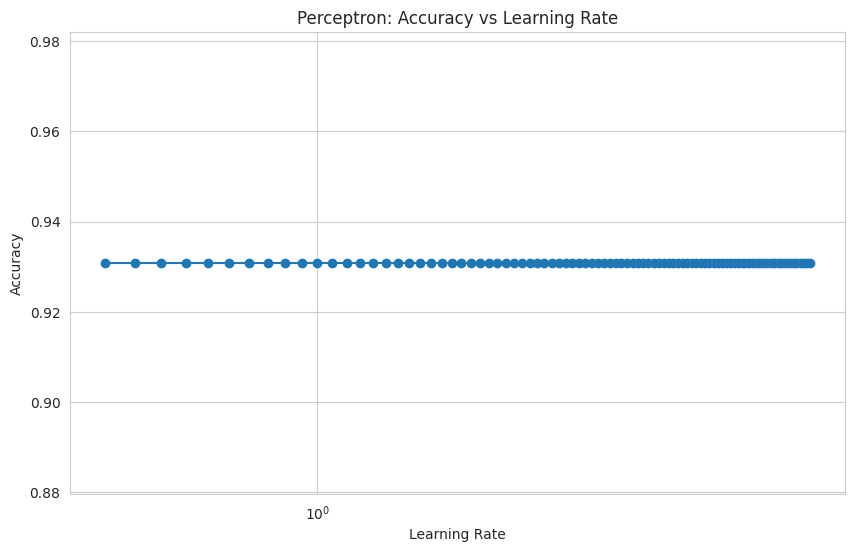

Best learning rate: 0.5 with accuracy: 0.9308


In [29]:
# Experiment with different learning rates
learning_rates = np.arange(0.5, 5.05, 0.05)
lr_scores = []

for lr in learning_rates:
    perceptron_temp = Perceptron(max_iter=1000, random_state=42, eta0=lr)
    perceptron_temp.fit(X_train_scaled, y_train)
    lr_scores.append(perceptron_temp.score(X_test_scaled, y_test))

# Plot learning rate vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, lr_scores, marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Perceptron: Accuracy vs Learning Rate')
plt.xscale('log')
plt.grid(True)
plt.show()

print(f"Best learning rate: {learning_rates[np.argmax(lr_scores)]} with accuracy: {max(lr_scores):.4f}")

### 5.3 Naive Bayes

In [30]:
# Create and train Naive Bayes model (Gaussian)
# Note: Use GaussianNB for continuous features, MultinomialNB for count data
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Make predictions
y_pred_nb = nb.predict(X_test_scaled)

# Evaluate the model
print("=== Naive Bayes (Gaussian) Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Cross-validation score
cv_scores_nb = cross_val_score(nb, X_train_scaled, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores_nb}")
print(f"Mean CV score: {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std() * 2:.4f})")

=== Naive Bayes (Gaussian) Results ===
Accuracy: 0.9310

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.00      0.01       402
           1       0.93      1.00      0.96      5408

    accuracy                           0.93      5810
   macro avg       0.80      0.50      0.49      5810
weighted avg       0.91      0.93      0.90      5810


Cross-validation scores: [0.93072289 0.93115318 0.93050775 0.92986231 0.9302776 ]
Mean CV score: 0.9305 (+/- 0.0009)


## 6. Model Comparison

=== Model Comparison ===
      Model  Accuracy  Precision   Recall  F1-Score
        KNN  0.943718   0.939211 0.943718  0.927985
 Perceptron  0.930809   0.866405 0.930809  0.897453
Naive Bayes  0.930981   0.912820 0.930981  0.898211


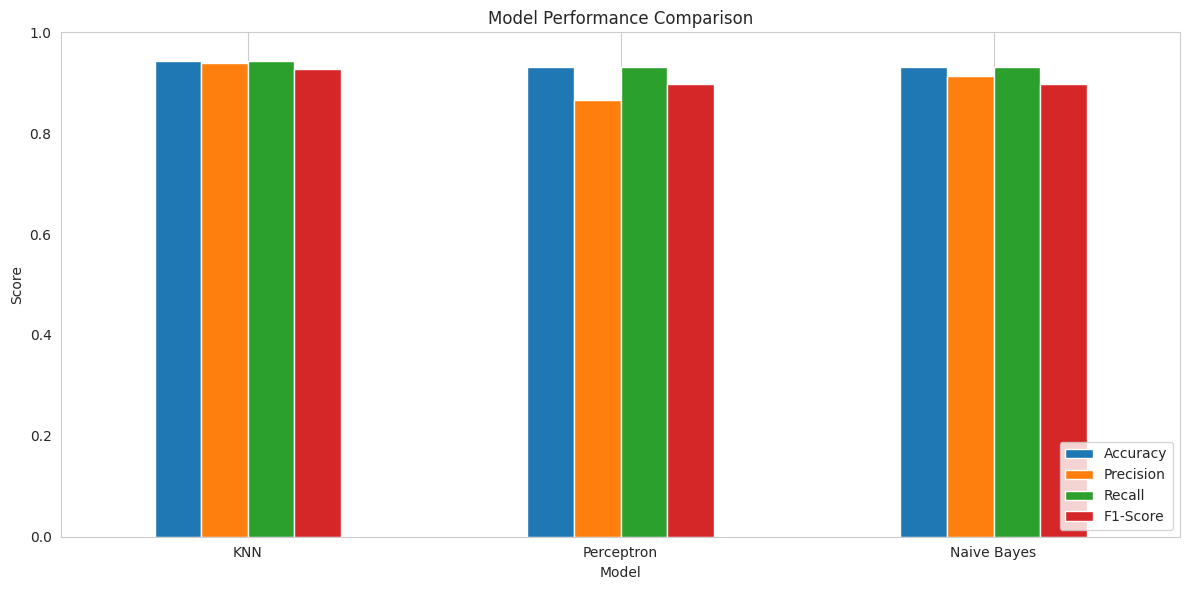

In [31]:
# Compare all models
models = {
    'KNN': (knn, y_pred_knn),
    'Perceptron': (perceptron, y_pred_perceptron),
    'Naive Bayes': (nb, y_pred_nb)
}

# Create comparison dataframe
comparison_data = []
for name, (model, y_pred) in models.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_data)
print("=== Model Comparison ===")
print(comparison_df.to_string(index=False))

# Visualize comparison
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## 7. Confusion Matrices

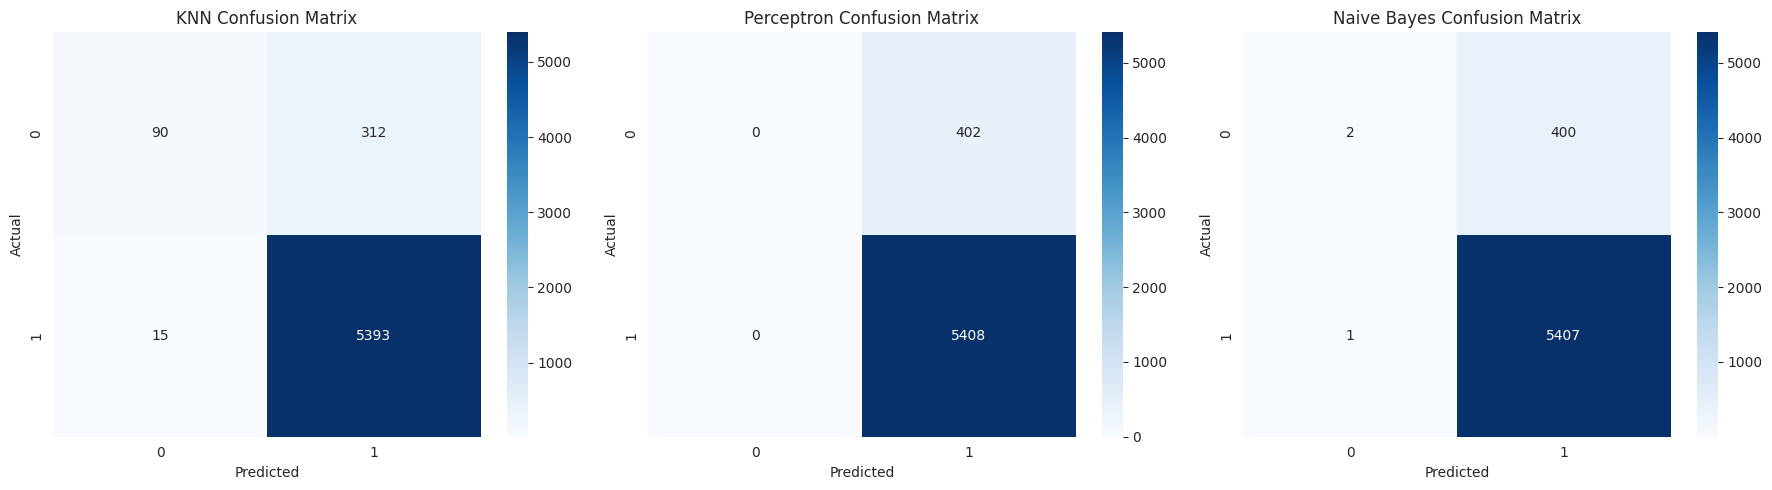

In [32]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, (model, y_pred)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Conclusions and Next Steps

### TODO: Based on your results, answer the following:
1. Which model performed best for this dataset?
2. Why do you think that model performed better?
3. What feature engineering could improve the results?
4. What hyperparameters should be tuned further?

### Potential improvements:
- Feature engineering (create new features)
- Handle imbalanced classes (SMOTE, class weights)
- More sophisticated hyperparameter tuning (GridSearchCV)
- Try ensemble methods
- Engineer categorical features differently

## 9. Making Predictions on New Cards

Now that your models are trained, you can predict whether a new card should be Commander-legal!

In [33]:
def predict_commander_legal(card_cmc, card_colors, card_type, model_choice='knn'):
    """
    Predict if a card should be Commander-legal based on its features.
    
    Parameters:
    - card_cmc: float - Converted mana cost (e.g., 3.0)
    - card_colors: str - Color(s) (e.g., "['R']", "['W', 'U']", or "Colorless")
    - card_type: str - Card type (e.g., "Creature — Human Wizard", "Instant")
    - model_choice: str - Which model to use: 'knn', 'perceptron', or 'naive_bayes'
    
    Returns:
    - prediction: 0 (not legal) or 1 (legal)
    - probability: confidence of the prediction (for some models)
    """
    
    # Step 1: Create a features array
    new_card = pd.DataFrame({
        'cmc': [card_cmc],
        'colors': [card_colors],
        'type': [card_type]
    })
    
    # Step 2: Encode categorical features using the SAME encoders from training
    for col in categorical_columns:
        if col in new_card.columns and col in label_encoders:
            try:
                # Transform using the fitted encoder
                new_card[col] = label_encoders[col].transform(new_card[col].astype(str))
            except ValueError as e:
                # If the category wasn't seen during training, find closest match or use most common
                print(f"⚠️  Warning: '{new_card[col].values[0]}' not seen in training for '{col}'")
                print(f"   Available values include: {list(label_encoders[col].classes_[:5])}...")
                print(f"   Using most common value as default")
                # Use the most common encoded value (typically 0 or the first class)
                new_card[col] = 0
    
    # Step 3: Get feature values in the correct order
    X_new = new_card[feature_columns].values
    
    # Step 4: Scale the features using the SAME scaler from training
    X_new_scaled = scaler.transform(X_new)
    
    # Step 5: Make prediction
    if model_choice == 'knn':
        prediction = knn.predict(X_new_scaled)[0]
        # KNN can give probability estimates
        proba = knn.predict_proba(X_new_scaled)[0]
    elif model_choice == 'perceptron':
        prediction = perceptron.predict(X_new_scaled)[0]
        proba = None  # Perceptron doesn't provide probabilities
    elif model_choice == 'naive_bayes':
        prediction = nb.predict(X_new_scaled)[0]
        proba = nb.predict_proba(X_new_scaled)[0]
    else:
        raise ValueError("model_choice must be 'knn', 'perceptron', or 'naive_bayes'")
    
    # Return results
    result = "Commander-Legal ✓" if prediction == 1 else "NOT Commander-Legal ✗"
    print(f"\n{'='*50}")
    print(f"Card Features:")
    print(f"  CMC: {card_cmc}")
    print(f"  Colors: {card_colors}")
    print(f"  Type: {card_type}")
    print(f"{'='*50}")
    print(f"Prediction ({model_choice.upper()}): {result}")
    if proba is not None:
        print(f"Confidence: Not Legal={proba[0]:.1%}, Legal={proba[1]:.1%}")
    print(f"{'='*50}\n")
    
    return prediction, proba

### Try Your Own Card!

Modify the values below to test any card you want.  
**Important:** Use the exact format shown above for colors and types!

In [35]:
models = ['knn', 'perceptron', 'naive_bayes']

# Edit these values to test your own card
my_card_cmc = 0
my_card_colors = "Colorless"  # e.g., "['R']", "['W', 'U']", or "Colorless" for colorless
my_card_type = "Artifact"

# Make prediction with the 3 models
for model in models:
    predict_commander_legal(my_card_cmc, my_card_colors, my_card_type, model_choice=model)



Card Features:
  CMC: 0
  Colors: Colorless
  Type: Artifact
Prediction (KNN): Commander-Legal ✓
Confidence: Not Legal=14.3%, Legal=85.7%


Card Features:
  CMC: 0
  Colors: Colorless
  Type: Artifact
Prediction (PERCEPTRON): Commander-Legal ✓


Card Features:
  CMC: 0
  Colors: Colorless
  Type: Artifact
Prediction (NAIVE_BAYES): Commander-Legal ✓
Confidence: Not Legal=0.0%, Legal=100.0%

